---
image: example.gif
pub-info:
    abstract: |
        Not all resources are static - sometimes, a resource may need to move to where our entities are, 
        not the other way around, or move to where another static resource is. 
        In this example we look at a case where we have more treatment rooms than nurses, so the nurses 
        move between rooms as they are needed.
filters:
  - quarto
  - line-highlight
execute: 
  enabled: true
---

# Visualising Moving Resources

Not all resources are static - sometimes, they may be the thing moving to the entity rather than the other way around. 

Before trying to visualise this, the first thing to consider is whether it's necessary! It may be sufficient to explain to stakeholders that this is a simplified representation of the process. 

However, in some cases, it may be absolutely necessary for aiding in understanding and getting your stakeholders on board with the model. 

In this example, we will look at how we could visualise a scenario with patients in a hospital. 

They will be triaged by a receptionist, then will go to a waiting area, where they will wait for a cubicle to become free. 

At the point a cubicle is available, a nurse resource will leave the nurse's station and join them in the cubicle, where they will be treated and then discharged. 

In [1]:
#| echo: false
import plotly.io as pio
pio.renderers.default = "iframe"

In [2]:
#| code-fold: true
#| code-summary: "Show the imports"
import simpy
import pandas as pd
import numpy as np
from vidigi.logging import EventLogger
from vidigi.resources import VidigiStore
from sim_tools.distributions import Exponential, Lognormal
from vidigi.utils import create_event_position_df, EventPosition
from vidigi.prep import reshape_for_animations, generate_animation_df
from vidigi.animation import generate_animation, animate_activity_log

In [3]:
#| code-fold: true
#| code-summary: "Show the global parameter class code"
# Class to store global parameter values.  We don't create an instance of this
# class - we just refer to the class blueprint itself to access the numbers
# inside.
class g:
    '''
    Create a scenario to parameterise the simulation model

    Parameters:
    -----------
    random_number_set: int, optional (default=DEFAULT_RNG_SET)
        Set to control the initial seeds of each stream of pseudo
        random numbers used in the model.

    n_cubicles: int
        The number of treatment cubicles

    trauma_treat_mean: float
        Mean of the trauma cubicle treatment distribution (Lognormal)

    trauma_treat_var: float
        Variance of the trauma cubicle treatment distribution (Lognormal)

    arrival_rate: float
        Set the mean of the exponential distribution that is used to sample the
        inter-arrival time of patients

    sim_duration: int
        The number of time units the simulation will run for

    number_of_runs: int
        The number of times the simulation will be run with different random number streams

    '''
    n_triage_staff = 2
    n_cubicles = 4
    n_nurses = 2

    triage_mean = 5
    triage_var = 3
    trauma_treat_mean = 40
    trauma_treat_var = 15

    arrival_rate = 20

    sim_duration = 60 * 24 * 10
    number_of_runs = 5

In [4]:
#| code-fold: true
#| code-summary: "Show the patient class code"
class Patient:
    '''
    Class defining details for a patient entity
    '''
    def __init__(self, p_id):
        '''
        Constructor method

        Params:
        -----
        identifier: int
            a numeric identifier for the patient.
        '''
        self.id = p_id


Our model class is the only place where we make any significant changes compared to a normal vidigi animation. 

The key thing we will need to do is to record any use of our mobile resource - in this case, a nurse - as a resource use start and end. 

However, unlike the normal resource use recording, where our entity ID is the identifier that indicates the entity that gets the resource - in this case, our patients - we will instead be giving our nurses their own unique ID so they can be tracked throughout the vidigi animation. 

However, our resource IDs of 1 and 2 will inevitably overlap with some of our generated patient IDs. To overcome this, we add a suitably large number to the start of our
identifier when referring to the nurses - e.g. `99999 + nurse_resource.id_attribute`. 

This ensures each nurse gets their own identifier, but it doesn't overwrite a patient. 

We will still want to know what patient they are attending, though, so we can borrow the positioning of the patient to ensure our nurses appear in the correct place in the animation. 

To do this, we will pass an extra parameter in when we use our logging functions, tracking the patient identifier as well as the entity identifier. 
Most of the time, these will be the same as each other - but crucially, when it comes to the nurse use step, they will differ. 

In [5]:
# Class representing our model of the clinic.
class Model:
    '''
    Simulates the simplest minor treatment process for a patient

    1. Arrive
    2. Examined/treated by nurse when one available
    3. Discharged
    '''
    # Constructor to set up the model for a run.  We pass in a run number when
    # we create a new model.
    def __init__(self, run_number):
        # Create a SimPy environment in which everything will live
        self.env = simpy.Environment()

        # Store the passed in run number
        self.run_number = run_number

        # By passing in the env we've created, the logger will default to the simulation
        # time when populating the time column of our event logs
        self.logger = EventLogger(env=self.env, run_number=self.run_number)

        # Create a patient counter (which we'll use as a patient ID)
        self.patient_counter = 0

        # Create an empty list to hold our patients
        self.patients = []

        # Create our distributions
        self.init_distributions()

        # Create our resources
        self.init_resources()

        ###########################################################
        # KEY ADDITION
        # So we know when to put our nurses back at their desk, we
        # need to keep our count of the number of patients waiting
        # for a nurse up to date.
        # Create a list we can use to track the length of the queue
        # for the nurses
        #############################################################
        self.nurse_queue = [] #<<

    def init_distributions(self):
        ss = np.random.SeedSequence(self.run_number)
        seeds = ss.spawn(3)
        self.patient_inter_arrival_dist = Exponential(mean = g.arrival_rate,
                                                      random_seed = seeds[0])

        self.triage_dist = Lognormal(mean = g.trauma_treat_mean,
                                    stdev = g.trauma_treat_var,
                                    random_seed = seeds[1])

        self.treat_dist = Lognormal(mean = g.trauma_treat_mean,
                                    stdev = g.trauma_treat_var,
                                    random_seed = seeds[2])

    def init_resources(self):
        '''
        Init the number of resources

        Resource list:
            1. Nurses/treatment bays (same thing in this model)

        '''
        self.triage_staff = VidigiStore(self.env, num_resources=g.n_triage_staff)
        self.treatment_cubicles = VidigiStore(self.env, num_resources=g.n_cubicles)
        self.nurses = VidigiStore(self.env, num_resources=g.n_nurses)

    # A generator function that represents the DES generator for patient
    # arrivals
    def generator_patient_arrivals(self):
        # We use an infinite loop here to keep doing this indefinitely whilst
        # the simulation runs
        while True:
            # Increment the patient counter by 1 (this means our first patient
            # will have an ID of 1)
            self.patient_counter += 1

            # Create a new patient - an instance of the Patient Class we
            # defined above.  Remember, we pass in the ID when creating a
            # patient - so here we pass the patient counter to use as the ID.
            p = Patient(self.patient_counter)

            # Store patient in list for later easy access
            self.patients.append(p)

            # Tell SimPy to start up the attend_clinic generator function with
            # this patient (the generator function that will model the
            # patient's journey through the system)
            self.env.process(self.attend_clinic(p))

            # Randomly sample the time to the next patient arriving.  Here, we
            # sample from an exponential distribution (common for inter-arrival
            # times), and pass in a lambda value of 1 / mean.  The mean
            # inter-arrival time is stored in the g class.
            # Freeze this instance of this function in place until the
            # inter-arrival time we sampled above has elapsed.  Note - time in
            # SimPy progresses in "Time Units", which can represent anything
            # you like (just make sure you're consistent within the model)
            yield self.env.timeout(self.patient_inter_arrival_dist.sample())

    # A generator function that represents the pathway for a patient going
    # through the clinic.
    # The patient object is passed in to the generator function so we can
    # extract information from / record information to it
    def attend_clinic(self, patient):
        self.logger.log_arrival(
            entity_id=patient.id,
            patient_id=patient.id #<<
            )

        self.arrival = self.env.now

        self.logger.log_queue(
            entity_id=patient.id,
            event="triage_wait_begins",
            patient_id=patient.id #<<
            )

        # Be triaged
        with self.triage_staff.request() as req:
            triage_staff_member = yield req

            self.logger.log_resource_use_start(
                entity_id=patient.id,
                event="triage_begins",
                resource_id=triage_staff_member.id_attribute,
                patient_id=patient.id #<<
                )

            yield self.env.timeout(self.triage_dist.sample())

            self.logger.log_resource_use_end(
                entity_id=patient.id,
                event="triage_ends",
                resource_id=triage_staff_member.id_attribute,
                patient_id=patient.id #<<
                )

        self.logger.log_queue(
            entity_id=patient.id,
            event="treatment_wait_begins",
            patient_id=patient.id #<<
            )

        with self.treatment_cubicles.request() as req:

            # Seize a treatment resource when available
            treatment_cubicle_resource = yield req

            #########################################
            # KEY ADDITION
            # From here on in, we will be recording both an
            # entity id and a patient id attribute with our
            # logger.
            # Sometimes these may be one and the same, but
            # it's still important to record both as they will
            # help us join up important parts later.
            # We could call patient ID anything we want here -
            # but effectively we're trying to separate an entity ID
            # (one per icon in vidigi, including our nurse resources)
            # from our actual patient identifier
            ########################################

            self.logger.log_resource_use_start(
                entity_id=patient.id,
                event="treatment_cubicle_use_begins",
                resource_id=treatment_cubicle_resource.id_attribute,
                patient_id=patient.id
                )

            ##################################################################
            # KEY ADDITION
            # So we know when to put our nurses back at their desk, we
            # need to keep our count of the number of patients waiting
            # for a nurse up to date.
            # We need to track that this patient is now waiting for a nurse.
            ##################################################################
            self.nurse_queue.append(patient)

            with self.nurses.request() as req:

                self.logger.log_queue(
                    entity_id=patient.id,
                    event="nurse_wait_begins",
                    patient_id=patient.id #<<
                    )

                nurse_resource = yield req

                ###########################################################
                # KEY ADDITION
                # So we know when to put our nurses back at their desk, we
                # need to keep our count of the number of patients waiting
                # for a nurse up to date.
                # At this point they're no longer waiting for a nurse, so
                # we remove them.
                #############################################################
                self.nurse_queue.remove(patient) #<<

                #########################################
                # KEY ADDITION
                # Here our patient ID represents the patient being seen,
                # but our entity ID changes to be the entity attribute of
                # the nurse seeing the patient.
                # Note that we've added a large number to the entity ID for the nurse
                # so that it won't overlap with the ID of an actual entity - in the case
                # of this model, a patient - that is generated within the model.
                ##########################################

                self.logger.log_resource_use_start( #<<
                    entity_id=99999+nurse_resource.id_attribute, #<<
                    event="nurse_treatment_begins", #<<
                    resource_id=nurse_resource.id_attribute, #<<
                    patient_id=patient.id #<<
                    ) #<<

                # sample treatment duration
                yield self.env.timeout(self.treat_dist.sample())

                #########################################
                # KEY ADDITION
                # Note that again we are recording the modified nurse entity ID as our
                # entity ID, and our patient's identifier in the patient_id column
                # #########################################

                self.logger.log_resource_use_end( #<<
                    entity_id=99999+nurse_resource.id_attribute, #<<
                    event="nurse_treatment_ends", #<<
                    resource_id=nurse_resource.id_attribute, #<<
                    patient_id=patient.id #<<
                    ) #<<

                #########################################
                # KEY ADDITION
                # In this case, patient_id = entity_id
                ######################################
                self.logger.log_resource_use_end( #<<
                    entity_id=patient.id, #<<
                    event="treatment_cubicle_use_ends", #<<
                    resource_id=treatment_cubicle_resource.id_attribute, #<<
                    patient_id=patient.id #<<
                    ) #<<

                ######################################################################
                # KEY ADDITION
                # if noone is queueing for a nurse, go back to the nurse desk
                # (or whatever your 'holding space' is for your mobile resources)
                # when they are not in use
                #######################################################################
                if len(self.nurse_queue) == 0: #<<
                    self.logger.log_resource_use_start( #<<
                        entity_id=99999+nurse_resource.id_attribute, #<<
                        event="nurse_at_desk", #<<
                        resource_id=nurse_resource.id_attribute, #<<
                        patient_id=patient.id #<<
                    ) #<<


        self.logger.log_departure(
            entity_id=patient.id
            )

    # The run method starts up the DES entity generators, runs the simulation,
    # and in turns calls anything we need to generate results for the run
    def run(self):
        #####################################################################
        # KEY ADDITION
        # For each of our nurses, record that they are starting at their desk
        # Note that we also need to ensure each nurse has an arrival at the
        # very start of the model, and a departure at the very end
        # If we miss this out, these entities won't be picked up by the
        # animation functions
        #####################################################################
        for nurse in self.nurses.items: #<<
            self.logger.log_arrival( #<<
                entity_id=99999+nurse.id_attribute, #<<
            ) #<<

            self.logger.log_resource_use_start( #<<
                entity_id=99999+nurse.id_attribute, #<<
                event="nurse_at_desk", #<<
                resource_id=nurse.id_attribute #<<
            ) #<<

            # KEY ADDITION: For each of our nurses, record them exiting the model
            self.logger.log_departure( #<<
                entity_id=99999+nurse.id_attribute, #<<
                # Override the time attribute with the model end
                # This is more reliable than putting it after the self.env.run call below
                time=g.sim_duration #<<
            )

        # Start up our DES entity generators that create new patients.  We've
        # only got one in this model, but we'd need to do this for each one if
        # we had multiple generators.
        self.env.process(self.generator_patient_arrivals())

        # Run the model for the duration specified in g class
        self.env.run(until=g.sim_duration)


In [6]:
#| code-fold: true
#| code-summary: "Show the trial class code"
class Trial:
    def  __init__(self):
        self.all_event_logs = []
        self.trial_results_df = pd.DataFrame()

        self.run_trial()

    # Method to run a trial
    def run_trial(self):
        # Run the simulation for the number of runs specified in g class.
        # For each run, we create a new instance of the Model class and call its
        # run method, which sets everything else in motion.  Once the run has
        # completed, we grab out the stored run results (just mean queuing time
        # here) and store it against the run number in the trial results
        # dataframe.
        for run in range(1, g.number_of_runs+1):
            my_model = Model(run)
            my_model.run()

            self.all_event_logs.append(my_model.logger)

        self.trial_results = pd.concat(
            [run_results.to_dataframe() for run_results in self.all_event_logs]
            )

In [7]:
clinic_simulation = Trial()

Let's take a general look at our logs.

In [8]:
clinic_simulation.all_event_logs[0].to_dataframe()

,entity_id,event_type,event,time,run_number,resource_id,patient_id
0,100000,arrival_departure,arrival,0.000000,1,NaN,NaN
1,100000,resource_use,nurse_at_desk,0.000000,1,1.0,NaN
2,100000,arrival_departure,depart,14400.000000,1,NaN,NaN
3,100001,arrival_departure,arrival,0.000000,1,NaN,NaN
4,100001,resource_use,nurse_at_desk,0.000000,1,2.0,NaN
...,...,...,...,...,...,...,...
7815,700,queue,treatment_wait_begins,14374.107993,1,NaN,700.0
7816,702,resource_use,triage_begins,14374.107993,1,2.0,702.0
7817,701,resource_use_end,triage_ends,14382.765924,1,1.0,701.0
7818,701,queue,treatment_wait_begins,14382.765924,1,NaN,701.0


What events do we have, and how many of each?

In [9]:
clinic_simulation.all_event_logs[0].to_dataframe().value_counts('event')

event
arrival                         732
triage_wait_begins              730
triage_begins                   703
treatment_wait_begins           701
triage_ends                     701
nurse_wait_begins               697
treatment_cubicle_use_begins    697
depart                          695
nurse_treatment_begins          695
nurse_treatment_ends            693
treatment_cubicle_use_ends      693
nurse_at_desk                    83
Name: count, dtype: int64

Let's also visualise it as a dfg. We can see that it's rarer for a nurse to be at the desk before treatment than for them to move straight from one cubicle to the other. 

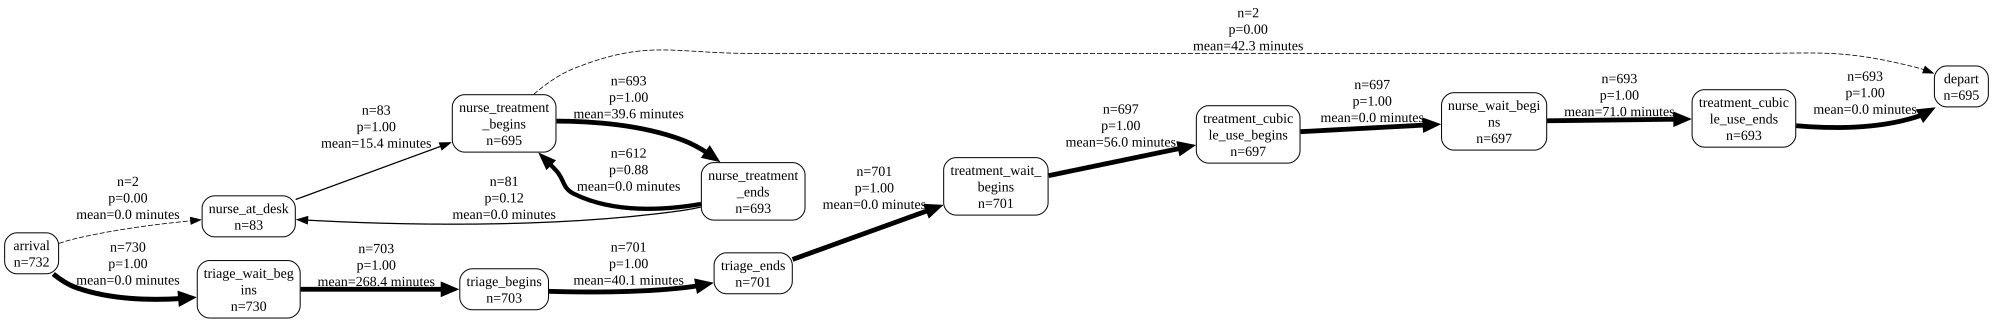

In [10]:
clinic_simulation.all_event_logs[0].generate_dfg()

Let's also check what entries we have for our nurse objects.

In [11]:
df = clinic_simulation.all_event_logs[0].to_dataframe()

df[df["entity_id"] >= 99999].sort_values('time')


,entity_id,event_type,event,time,run_number,resource_id,patient_id
0,100000,arrival_departure,arrival,0.000000,1,NaN,NaN
1,100000,resource_use,nurse_at_desk,0.000000,1,1.0,NaN
3,100001,arrival_departure,arrival,0.000000,1,NaN,NaN
4,100001,resource_use,nurse_at_desk,0.000000,1,2.0,NaN
23,100000,resource_use,nurse_treatment_begins,92.271321,1,1.0,1.0
...,...,...,...,...,...,...,...
7798,100001,resource_use_end,nurse_treatment_ends,14357.550593,1,2.0,692.0
7804,100000,resource_use_end,nurse_treatment_ends,14357.907795,1,1.0,693.0
7807,100000,resource_use,nurse_treatment_begins,14357.907795,1,1.0,695.0
2,100000,arrival_departure,depart,14400.000000,1,NaN,NaN


## Animating

Before we start including the movement of the nurses, we'll just set up a quick animation to sort out our layout and check the model is largely working as expected. 

In [12]:
triage_wait_begins =EventPosition(event='triage_wait_begins', x=160, y=375, label="Waiting for Triage")
triage_begins = EventPosition(event='triage_begins', x=160, y=315, resource='n_triage_staff', label="Being Triaged")
treatment_wait_begins = EventPosition(event='treatment_wait_begins', x=160, y=160, label="Waiting for Treatment Cubicle")
treatment_cubicle_use_begins = EventPosition(event='treatment_cubicle_use_begins', x=160, y=90, resource='n_cubicles', label="In Treatment Cubicle")
depart = EventPosition(event='depart', x=670, y=330, label="Exit")

event_position_df = create_event_position_df([
    triage_wait_begins,
    triage_begins,
    treatment_wait_begins,
    treatment_cubicle_use_begins,
    depart
])

In [13]:
single_run = clinic_simulation.all_event_logs[0].to_dataframe()

animate_activity_log(
        event_log=single_run,
        event_position_df=event_position_df,
        scenario=g(),
        debug_mode=True,
        setup_mode=False,
        every_x_time_units=1,
        include_play_button=True,
        entity_icon_size=20,
        resource_icon_size=20,
        gap_between_entities=8,
        gap_between_queue_rows=25,
        plotly_height=700,
        frame_duration=200,
        plotly_width=1200,
        override_x_max=300,
        override_y_max=500,
        limit_duration=int(g.sim_duration/10),
        wrap_queues_at=25,
        step_snapshot_max=125,
        time_display_units="dhm",
        display_stage_labels=True,
    )

Animation function called at 15:03:41


Iteration through time-unit-by-time-unit logs complete 15:03:50
Snapshot df concatenation complete at 15:03:50


Reshaped animation dataframe finished construction at 15:03:50
Placement dataframe started construction at 15:03:50
Placement dataframe finished construction at 15:03:50


Output animation generation complete at 15:03:58
Total Time Elapsed: 17.71 seconds


However, if we watch the animation above, no-one seems to end up in a cubicle, despite the fact that we know this happens thanks to our DFG. 

What is happening is that patients start waiting for a nurse the second they get a cubicle, so this is showing up as the most up to date event. 

Therefore, we want to limit our event dataframe to only the events we want to visualise. In this case, we can just exclude any nurse-related events for now. 

In [14]:
animate_activity_log(
        event_log=single_run[~single_run["event"].str.contains("nurse")],
        event_position_df=event_position_df,
        scenario=g(),
        debug_mode=True,
        setup_mode=False,
        every_x_time_units=1,
        include_play_button=True,
        entity_icon_size=20,
        resource_icon_size=20,
        gap_between_entities=6,
        gap_between_queue_rows=25,
        plotly_height=700,
        frame_duration=200,
        plotly_width=1200,
        override_x_max=300,
        override_y_max=500,
        limit_duration=int(g.sim_duration/10),
        wrap_queues_at=25,
        step_snapshot_max=125,
        time_display_units="dhm",
        display_stage_labels=True,
    )

Animation function called at 15:03:59


Iteration through time-unit-by-time-unit logs complete 15:04:10


Snapshot df concatenation complete at 15:04:10
Reshaped animation dataframe finished construction at 15:04:10
Placement dataframe started construction at 15:04:10
Placement dataframe finished construction at 15:04:10


Output animation generation complete at 15:04:18
Total Time Elapsed: 18.51 seconds


This is now showing patients being treated - but we will need to do some manual adjustments to get our nurses to appear.

## Enhancing the animation - adding nurse movement

First, we are going to swap over to the three separate animation functions to allow us to make changes to intermediate steps. 

:::{.callout-note}
Note that we are excluding the nurse steps from our function calls at this stage.

This is so we can mirror the animation we just created, ensuring that the point at which the patients get assigned to a cubicle is what gets animated rather than immediately being overruled by the fact that they start waiting for a nurse to get assigned. 
:::

In [15]:
full_entity_df = reshape_for_animations(
    ### pass in our event log excluding the nurse stage
    event_log = single_run[~single_run["event"].str.contains("nurse")],
    every_x_time_units=1,
    limit_duration=int(g.sim_duration/10),
    step_snapshot_max=50,
)

In [16]:
full_entity_df_plus_pos = generate_animation_df(
    full_entity_df=full_entity_df,
    event_position_df=event_position_df,
    step_snapshot_max=50,
    wrap_queues_at=25,
    gap_between_entities=8,
    gap_between_queue_rows=25,
)

full_entity_df_plus_pos.head()

,index,entity_id,event_type,event,time,run_number,resource_id,patient_id,rank,snapshot_time,x,y_final,label,resource,x_final,row,y,icon,opacity
13015,8,1,resource_use,triage_begins,0.0,1,1.0,1.0,1.0,0,160.0,315.0,Being Triaged,n_triage_staff,160.0,0.0,NaN,🧔🏼,1.0
13016,8,1,resource_use,triage_begins,0.0,1,1.0,1.0,1.0,1,160.0,315.0,Being Triaged,n_triage_staff,160.0,0.0,NaN,🧔🏼,1.0
13017,8,1,resource_use,triage_begins,0.0,1,1.0,1.0,1.0,2,160.0,315.0,Being Triaged,n_triage_staff,160.0,0.0,NaN,🧔🏼,1.0
13018,8,1,resource_use,triage_begins,0.0,1,1.0,1.0,1.0,3,160.0,315.0,Being Triaged,n_triage_staff,160.0,0.0,NaN,🧔🏼,1.0
13019,8,1,resource_use,triage_begins,0.0,1,1.0,1.0,1.0,4,160.0,315.0,Being Triaged,n_triage_staff,160.0,0.0,NaN,🧔🏼,1.0


Let's check what events we have at this stage.

In [17]:
full_entity_df_plus_pos.value_counts("event")

event
triage_wait_begins              5868
treatment_cubicle_use_begins    4372
arrival                         2882
triage_begins                   2649
treatment_wait_begins            699
depart                            63
Name: count, dtype: int64

Let's have a look at our nurse events.

In [18]:
full_entity_df_plus_pos[full_entity_df_plus_pos["event"].str.contains("nurse")]

,index,entity_id,event_type,event,time,run_number,resource_id,patient_id,rank,snapshot_time,x,y_final,label,resource,x_final,row,y,icon,opacity


Of course - we excluded them, so (correctly) there is nothing there. 

We'll now repeat these function calls for **all** events. 

:::{.callout-tip}
Note that we will filter down to just the nurse events **AFTER**.

This is important because of vidigi's reliance on entrance and exit points for entities, and this order of filtering and functions avoids running into issues related to that. 
:::

In [19]:
nurse_df = reshape_for_animations(
    # Pass in our full dataframe
    single_run,
    every_x_time_units=1,
    limit_duration=int(g.sim_duration/10),
    step_snapshot_max=50,
)

Let's also add another entry to our event positioning dataframe so our nurses have a desk they can sit at when there are no patients to be seen.

In our imaginary system, this is a more realistic representation of what happens than them sitting in the cubicle the patient was in until they need to go to the next patient. 

In [20]:
nurse_at_desk = EventPosition(event="nurse_at_desk", x=50, y=50, label="Nurses' Desk")

event_position_df = create_event_position_df([
    triage_wait_begins,
    triage_begins,
    treatment_wait_begins,
    treatment_cubicle_use_begins,
    nurse_at_desk, # Add the nurse desk position
    depart
])

Now we use `generate_animation_df` again on this event positioning dataframe with the full data, remembering that at this point, we are including all events still. 

We'll preemptively call this 'nurse_df_plus_pos' to reflect the fact that we'll filter it down to just nurse events in a moment. 

In [21]:
nurse_df_plus_pos = generate_animation_df(
    full_entity_df=nurse_df,
    event_position_df=event_position_df,
    step_snapshot_max=50,
    wrap_queues_at=25,
    gap_between_entities=8,
    gap_between_queue_rows=25,
)


Now we filter.

In [22]:
nurse_df_plus_pos = (
    nurse_df_plus_pos[nurse_df_plus_pos["event"]
                      .isin(["nurse_treatment_begins", "nurse_treatment_ends", "nurse_at_desk"])]
                      .copy()
    )

nurse_df_plus_pos

,index,entity_id,event_type,event,time,run_number,resource_id,patient_id,rank,snapshot_time,x,y_final,label,resource,x_final,row,y,icon,opacity
13651,1,100000,resource_use,nurse_at_desk,0.0000,1,1.0,NaN,1.0,0,50.0,50.0,Nurses' Desk,None,50.0,0.0,NaN,👩🏾‍🔬,1.0
13652,1,100000,resource_use,nurse_at_desk,0.0000,1,1.0,NaN,1.0,1,50.0,50.0,Nurses' Desk,None,50.0,0.0,NaN,👩🏾‍🔬,1.0
13653,1,100000,resource_use,nurse_at_desk,0.0000,1,1.0,NaN,1.0,2,50.0,50.0,Nurses' Desk,None,50.0,0.0,NaN,👩🏾‍🔬,1.0
13654,1,100000,resource_use,nurse_at_desk,0.0000,1,1.0,NaN,1.0,3,50.0,50.0,Nurses' Desk,None,50.0,0.0,NaN,👩🏾‍🔬,1.0
13655,1,100000,resource_use,nurse_at_desk,0.0000,1,1.0,NaN,1.0,4,50.0,50.0,Nurses' Desk,None,50.0,0.0,NaN,👩🏾‍🔬,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16528,719,100001,resource_use,nurse_treatment_begins,1397.8899,1,2.0,63.0,1.0,1436,NaN,NaN,NaN,NaN,NaN,0.0,NaN,👩🏿‍✈️,1.0
16529,719,100001,resource_use,nurse_treatment_begins,1397.8899,1,2.0,63.0,1.0,1437,NaN,NaN,NaN,NaN,NaN,0.0,NaN,👩🏿‍✈️,1.0
16530,719,100001,resource_use,nurse_treatment_begins,1397.8899,1,2.0,63.0,1.0,1438,NaN,NaN,NaN,NaN,NaN,0.0,NaN,👩🏿‍✈️,1.0
16531,719,100001,resource_use,nurse_treatment_begins,1397.8899,1,2.0,63.0,1.0,1439,NaN,NaN,NaN,NaN,NaN,0.0,NaN,👩🏿‍✈️,1.0


Let's change the icons for these events to a healthcare worker icon. 

:::{.callout-tip}
You could create a dictionary with an icon per resource and map this to the icon column. This would
allow you to ensure each different nurse had their own consistent icon. 
:::

In [23]:
nurse_df_plus_pos["icon"] = "🧑🏼‍⚕️"

While we haven't provided a position for these treatment activities to take place at, they do still appear in our dataframe. However, as they have no x and y coordinates assigned, they won't appear. 

Therefore, we want to assign appropriate positions for them. 

The main thing we can do is **link them up with the relevant patient entity at the relevant point in time.** 

What we will do now is just grab the rows from our previous dataframe - the one with all of the other, non-nurse events in. 

In [24]:
resource_use_position_df = (
    full_entity_df_plus_pos[full_entity_df_plus_pos["event"]=="treatment_cubicle_use_begins"].copy()
    )

We then filter down to just the relevant columns. 

:::{.callout-tip}
We filter the columns here so we don't end up with duplicated column names after the join. 
:::

In [25]:
resource_use_position_df = resource_use_position_df[["patient_id","snapshot_time", "x_final","y_final"]]

resource_use_position_df

,patient_id,snapshot_time,x_final,y_final
12952,1.0,93,160.0,90.0
12953,1.0,94,160.0,90.0
12954,1.0,95,160.0,90.0
12955,1.0,96,160.0,90.0
12956,1.0,97,160.0,90.0
...,...,...,...,...
12732,66.0,1436,150.0,90.0
12733,66.0,1437,150.0,90.0
12734,66.0,1438,150.0,90.0
12735,66.0,1439,150.0,90.0


We can now replace the relevant values in our nurse df with these positions. 

We do this by joining the dataframe of nurse events to the positions of the entities - our patients - when they are in 
the 'treatment_cubicle_use_begins' (our **static** resource) stage. 

This grabs the x and y position of each individual patient so we can use it to position the relevant nurse with the relevant patient. 

This is why we recorded that extra patient_id attribute in our logging steps - so we can join on it at this stage, as our nurses have
a different entity ID and so wouldn't otherwise have a record of which patient they were seeing at that time. 

In [26]:
nurse_df_plus_pos = (
    nurse_df_plus_pos
    # Get rid of our existing x and y coordinates for the nurses, which are just blank anyway
    .drop(columns=["x_final","y_final"])
    # Ensure we use the left (nurse_df_plus_pos) as the source of truth so we retain the rows
    # for the desk time too, which won't have an equivalent in the main resource use dataframe
    .merge(resource_use_position_df, on=["patient_id", "snapshot_time"], how="left")
    )

nurse_df_plus_pos

,index,entity_id,event_type,event,time,run_number,resource_id,patient_id,rank,snapshot_time,x,label,resource,row,y,icon,opacity,x_final,y_final
0,1,100000,resource_use,nurse_at_desk,0.0000,1,1.0,NaN,1.0,0,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,NaN,NaN
1,1,100000,resource_use,nurse_at_desk,0.0000,1,1.0,NaN,1.0,1,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,NaN,NaN
2,1,100000,resource_use,nurse_at_desk,0.0000,1,1.0,NaN,1.0,2,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,NaN,NaN
3,1,100000,resource_use,nurse_at_desk,0.0000,1,1.0,NaN,1.0,3,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,NaN,NaN
4,1,100000,resource_use,nurse_at_desk,0.0000,1,1.0,NaN,1.0,4,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2877,719,100001,resource_use,nurse_treatment_begins,1397.8899,1,2.0,63.0,1.0,1436,NaN,NaN,NaN,0.0,NaN,🧑🏼‍⚕️,1.0,130.0,90.0
2878,719,100001,resource_use,nurse_treatment_begins,1397.8899,1,2.0,63.0,1.0,1437,NaN,NaN,NaN,0.0,NaN,🧑🏼‍⚕️,1.0,130.0,90.0
2879,719,100001,resource_use,nurse_treatment_begins,1397.8899,1,2.0,63.0,1.0,1438,NaN,NaN,NaN,0.0,NaN,🧑🏼‍⚕️,1.0,130.0,90.0
2880,719,100001,resource_use,nurse_treatment_begins,1397.8899,1,2.0,63.0,1.0,1439,NaN,NaN,NaN,0.0,NaN,🧑🏼‍⚕️,1.0,130.0,90.0


We'll apply a slight offset to the nurses' vertical positions so they don't overlap the entity icons. 

In [27]:
nurse_df_plus_pos["y_final"] = nurse_df_plus_pos["y_final"] - 40

We also need to manually set the x and y position of our nurses at their desk. 

We'll apply an offset to their x position when at the desk so that they aren't all sitting on
top of each other. We do this by using their resource ID as a multiplier with the number of pixels we want to offset by. 

In [28]:
nurse_df_plus_pos["y_final"] = (
    nurse_df_plus_pos.apply(lambda row: nurse_at_desk.y
                            if row["event"]=="nurse_at_desk"
                            else row["y_final"],
                            axis=1)
    )

nurse_df_plus_pos["x_final"] = (
    # apply a horizontal offset so that nurses are staggered
    nurse_df_plus_pos.apply(lambda row: nurse_at_desk.x-(row["resource_id"]-1)*10
                            if row["event"]=="nurse_at_desk"
                            else row["x_final"], axis=1)
                            )

Let's take a look at what our resulting dataframe looks like.

In [29]:
nurse_df_plus_pos.sort_values(["entity_id","snapshot_time"]).head(20)

,index,entity_id,event_type,event,time,run_number,resource_id,patient_id,rank,snapshot_time,x,label,resource,row,y,icon,opacity,x_final,y_final
0,1,100000,resource_use,nurse_at_desk,0.0,1,1.0,NaN,1.0,0,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
1,1,100000,resource_use,nurse_at_desk,0.0,1,1.0,NaN,1.0,1,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
2,1,100000,resource_use,nurse_at_desk,0.0,1,1.0,NaN,1.0,2,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
3,1,100000,resource_use,nurse_at_desk,0.0,1,1.0,NaN,1.0,3,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
4,1,100000,resource_use,nurse_at_desk,0.0,1,1.0,NaN,1.0,4,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
5,1,100000,resource_use,nurse_at_desk,0.0,1,1.0,NaN,1.0,5,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
6,1,100000,resource_use,nurse_at_desk,0.0,1,1.0,NaN,1.0,6,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
7,1,100000,resource_use,nurse_at_desk,0.0,1,1.0,NaN,1.0,7,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
8,1,100000,resource_use,nurse_at_desk,0.0,1,1.0,NaN,1.0,8,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
9,1,100000,resource_use,nurse_at_desk,0.0,1,1.0,NaN,1.0,9,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0


Let's follow one nurse through a period where they spend some time at their desk, then with a patient. 

In [30]:
(nurse_df_plus_pos[(nurse_df_plus_pos["entity_id"]==100000) & (nurse_df_plus_pos["snapshot_time"]>=80) & (nurse_df_plus_pos["snapshot_time"]<110)])

,index,entity_id,event_type,event,time,run_number,resource_id,patient_id,rank,snapshot_time,x,label,resource,row,y,icon,opacity,x_final,y_final
80,1,100000,resource_use,nurse_at_desk,0.000000,1,1.0,NaN,1.0,80,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
81,1,100000,resource_use,nurse_at_desk,0.000000,1,1.0,NaN,1.0,81,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
82,1,100000,resource_use,nurse_at_desk,0.000000,1,1.0,NaN,1.0,82,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
83,1,100000,resource_use,nurse_at_desk,0.000000,1,1.0,NaN,1.0,83,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
84,1,100000,resource_use,nurse_at_desk,0.000000,1,1.0,NaN,1.0,84,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
85,1,100000,resource_use,nurse_at_desk,0.000000,1,1.0,NaN,1.0,85,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
86,1,100000,resource_use,nurse_at_desk,0.000000,1,1.0,NaN,1.0,86,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
87,1,100000,resource_use,nurse_at_desk,0.000000,1,1.0,NaN,1.0,87,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
88,1,100000,resource_use,nurse_at_desk,0.000000,1,1.0,NaN,1.0,88,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
89,1,100000,resource_use,nurse_at_desk,0.000000,1,1.0,NaN,1.0,89,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0


Let's check our 'at desk' events. 

In [31]:
(nurse_df_plus_pos[nurse_df_plus_pos["event"]=="nurse_at_desk"]).sort_values("snapshot_time")

,index,entity_id,event_type,event,time,run_number,resource_id,patient_id,rank,snapshot_time,x,label,resource,row,y,icon,opacity,x_final,y_final
0,1,100000,resource_use,nurse_at_desk,0.000000,1,1.0,NaN,1.0,0,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
1441,4,100001,resource_use,nurse_at_desk,0.000000,1,2.0,NaN,2.0,0,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,40.0,50.0
1,1,100000,resource_use,nurse_at_desk,0.000000,1,1.0,NaN,1.0,1,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
1442,4,100001,resource_use,nurse_at_desk,0.000000,1,2.0,NaN,2.0,1,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,40.0,50.0
2,1,100000,resource_use,nurse_at_desk,0.000000,1,1.0,NaN,1.0,2,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,50.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2755,683,100001,resource_use,nurse_at_desk,1312.566929,1,2.0,58.0,1.0,1314,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,40.0,50.0
2756,683,100001,resource_use,nurse_at_desk,1312.566929,1,2.0,58.0,1.0,1315,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,40.0,50.0
2757,683,100001,resource_use,nurse_at_desk,1312.566929,1,2.0,58.0,1.0,1316,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,40.0,50.0
2758,683,100001,resource_use,nurse_at_desk,1312.566929,1,2.0,58.0,1.0,1317,50.0,Nurses' Desk,None,0.0,NaN,🧑🏼‍⚕️,1.0,40.0,50.0


Finally, we join together our main dataframe of our entity positions and movements with our custom dataframe of our nurse positions and movements. 

:::{.callout-tip}
Make sure you sort the resulting dataframe by the snapshot time. 
:::

In [32]:
full_entity_df_plus_pos = pd.concat([full_entity_df_plus_pos, nurse_df_plus_pos]).sort_values("snapshot_time").reset_index(drop=True)

Let's view exactly what's going on with every entity for the first bit of the model.

In [33]:
full_entity_df_plus_pos.head(30)

,index,entity_id,event_type,event,time,run_number,resource_id,patient_id,rank,snapshot_time,x,y_final,label,resource,x_final,row,y,icon,opacity
0,8,1,resource_use,triage_begins,0.0,1,1.0,1.0,1.0,0,160.0,315.0,Being Triaged,n_triage_staff,160.0,0.0,NaN,🧔🏼,1.0
1,3,100001,arrival_departure,arrival,0.0,1,NaN,NaN,2.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,👩🏿‍✈️,1.0
2,1,100000,resource_use,nurse_at_desk,0.0,1,1.0,NaN,1.0,0,50.0,50.0,Nurses' Desk,None,50.0,0.0,NaN,🧑🏼‍⚕️,1.0
3,4,100001,resource_use,nurse_at_desk,0.0,1,2.0,NaN,2.0,0,50.0,50.0,Nurses' Desk,None,40.0,0.0,NaN,🧑🏼‍⚕️,1.0
4,0,100000,arrival_departure,arrival,0.0,1,NaN,NaN,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,👩🏾‍🔬,1.0
5,3,100001,arrival_departure,arrival,0.0,1,NaN,NaN,2.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,👩🏿‍✈️,1.0
6,8,1,resource_use,triage_begins,0.0,1,1.0,1.0,1.0,1,160.0,315.0,Being Triaged,n_triage_staff,160.0,0.0,NaN,🧔🏼,1.0
7,4,100001,resource_use,nurse_at_desk,0.0,1,2.0,NaN,2.0,1,50.0,50.0,Nurses' Desk,None,40.0,0.0,NaN,🧑🏼‍⚕️,1.0
8,1,100000,resource_use,nurse_at_desk,0.0,1,1.0,NaN,1.0,1,50.0,50.0,Nurses' Desk,None,50.0,0.0,NaN,🧑🏼‍⚕️,1.0
9,0,100000,arrival_departure,arrival,0.0,1,NaN,NaN,1.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,👩🏾‍🔬,1.0


It looks like our nurses have lots of arrival events! Let's filter those out. 

In [34]:
full_entity_df_plus_pos = full_entity_df_plus_pos[~((full_entity_df_plus_pos["entity_id"].isin([100000,100001])) & (full_entity_df_plus_pos["event_type"]=="arrival_departure"))]
full_entity_df_plus_pos.head(30)

,index,entity_id,event_type,event,time,run_number,resource_id,patient_id,rank,snapshot_time,x,y_final,label,resource,x_final,row,y,icon,opacity
0,8,1,resource_use,triage_begins,0.0,1,1.0,1.0,1.0,0,160.0,315.0,Being Triaged,n_triage_staff,160.0,0.0,NaN,🧔🏼,1.0
2,1,100000,resource_use,nurse_at_desk,0.0,1,1.0,NaN,1.0,0,50.0,50.0,Nurses' Desk,None,50.0,0.0,NaN,🧑🏼‍⚕️,1.0
3,4,100001,resource_use,nurse_at_desk,0.0,1,2.0,NaN,2.0,0,50.0,50.0,Nurses' Desk,None,40.0,0.0,NaN,🧑🏼‍⚕️,1.0
6,8,1,resource_use,triage_begins,0.0,1,1.0,1.0,1.0,1,160.0,315.0,Being Triaged,n_triage_staff,160.0,0.0,NaN,🧔🏼,1.0
7,4,100001,resource_use,nurse_at_desk,0.0,1,2.0,NaN,2.0,1,50.0,50.0,Nurses' Desk,None,40.0,0.0,NaN,🧑🏼‍⚕️,1.0
8,1,100000,resource_use,nurse_at_desk,0.0,1,1.0,NaN,1.0,1,50.0,50.0,Nurses' Desk,None,50.0,0.0,NaN,🧑🏼‍⚕️,1.0
12,4,100001,resource_use,nurse_at_desk,0.0,1,2.0,NaN,2.0,2,50.0,50.0,Nurses' Desk,None,40.0,0.0,NaN,🧑🏼‍⚕️,1.0
13,8,1,resource_use,triage_begins,0.0,1,1.0,1.0,1.0,2,160.0,315.0,Being Triaged,n_triage_staff,160.0,0.0,NaN,🧔🏼,1.0
14,1,100000,resource_use,nurse_at_desk,0.0,1,1.0,NaN,1.0,2,50.0,50.0,Nurses' Desk,None,50.0,0.0,NaN,🧑🏼‍⚕️,1.0
15,8,1,resource_use,triage_begins,0.0,1,1.0,1.0,1.0,3,160.0,315.0,Being Triaged,n_triage_staff,160.0,0.0,NaN,🧔🏼,1.0


That's much better!

Now we can generate the animation using this new dataframe. 

In [35]:
fig = generate_animation(
        full_entity_df_plus_pos=full_entity_df_plus_pos,
        event_position_df=event_position_df,
        scenario=g(),
        debug_mode=True,
        setup_mode=False,
        include_play_button=True,
        entity_icon_size=30,
        resource_icon_size=20,
        plotly_height=700,
        frame_duration=250,
        plotly_width=1200,
        override_x_max=300,
        override_y_max=500,
        time_display_units="dhm",
        display_stage_labels=True,
    )

fig

Output animation generation complete at 15:04:45


Our nurses now correctly move to different cubicles, heading back to their desk if there is no-one waiting to be seen. 